# Introduction
The primary objective of this lab is to familiarise you with the basic mechanics that allow you to get hold of satellite data for the purposes of carrying out machine learning. The second objective is for you to put into practice some of the theory that we covered in lectures 1 and 2, in order that you can start to understand some of the specific quirks and potentially powerful attributes of satellite data when it comes to applying machine learning techniques.

This lab has drawn upon the following sources, tutorials and repos:


*   https://geemap.org/
*   https://developers.google.com/earth-engine

Whenever you see a numbered question, e.g. '(1)', make sure that you answer it in the answer proforma and submit the resulting document on Canvas. Only submit in .docx or .pdf formats (we cannot open 'pages' etc docs on Canvas).

If you want to submit code as your 'working' OR we ask you to give your code as part of the answer, give a link in your proforma document to a Colab notebook that is stored in a place we can access (your own GitHub account for example!).

Some of the questions will be relatively simple and are designed to get you thinking about the nature of the code and what it is doing, whilst also requiring you to pull in theoretical knowledge from the lectures. Other questions are exercises that ask you to both apply this knowledege to a new challenge and/or require you to independently go and seek answers.

In all cases I encourage you to give it a go, even if you do not have the full answer. Particularly for the larger challenges ('Exercises'), marks are awarded for workings and I want to see your thought process in action via the code you write.

Use text comments as demonstrated in these lab instructions to explain your thinking and communicate with the person marking your work.

I use both comments above chunks of code to tell you the overall objectives of that code, and inline comments to highlight specific features and elements to be aware of (formatted like this to draw your attention '#<-').

You are expected to present outputs to a professional standard. This means maps must have scales, north arrows and legends that are readable. For a good guide to all matters professional figure drawing, see this Nature guide:
*    https://research-figure-guide.nature.com/figures/preparing-figures-our-specifications/.

A portion of the marks are for presentation and communication.

# Set up

In [43]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='geog761-503611')

In [44]:
# Install the geemap package (only needs to be run once, uncomment below and run it the first time you run this notebook in a session).
## !pip install geemap

In [45]:
import geemap

# Loading a map and displaying satellite data

In [46]:
# Use the built in functions to load an ipyleaflet basemap (this is a UI to explore and see what we are doing)
Map = geemap.Map(center=(-41, 172), zoom=4)
Map

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

In [47]:
# Specify a different kind of basemap to display data layers over
Map = geemap.Map(center=(-41, 172), zoom=4) #<- note the lat-lon coordinate pair here
Map.add_basemap("HYBRID")
Map

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

(1) Find and add the basemap 'OpenTopoMap' to the display window AND change the code so that the map opens and zooms to the city of Auckland.
Provide a link to your code in a notebook and the output as a figure in the answer proforma. (2 pts)

In [75]:
# ------------------------------------------------------------------------------------------------------------
## Applying slight alteration from previous chunk of code to change basemap from 'HYBRID' to 'OpenTopoMap'

# Specify a different kind of basemap to display data layers over
Map2 = geemap.Map(center=(-36.859546, 174.759615), zoom=11) # Altering coordinates to Auckland City
Map2.add_basemap("OpenTopoMap") # Changing basemap type as requested from the task
Map2 # Displaying the new map
# ------------------------------------------------------------------------------------------------------------

Map(center=[-36.859546, 174.759615], controls=(WidgetControl(options=['position', 'transparent_bg'], position=…

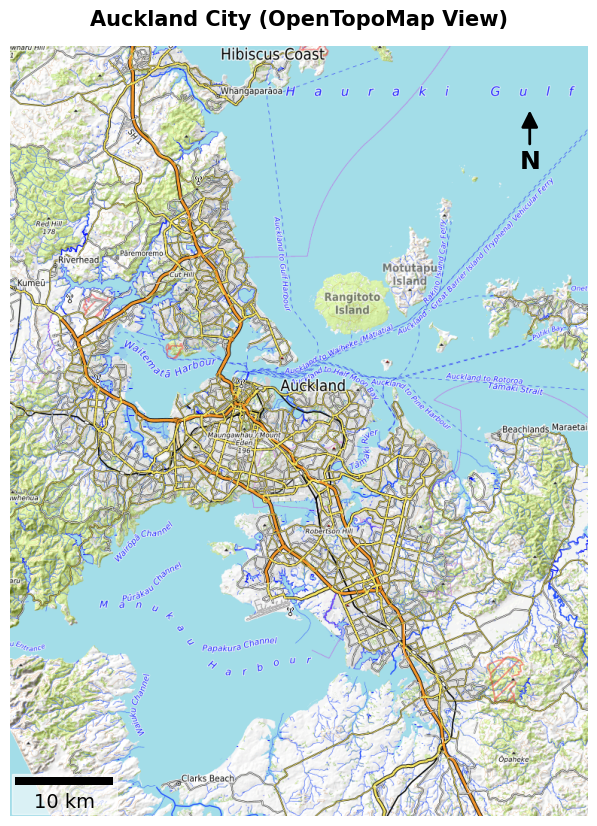

In [97]:
# ------------------------------------------------------------------------------

!pip install contextily matplotlib-scalebar -q

import contextily as cx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow
from matplotlib_scalebar.scalebar import ScaleBar

center = (-36.859546, 174.759615)  # Auckland City
delta = 0.2
zoom = 11

west, east = center[1] - delta, center[1] + delta
south, north = center[0] - delta, center[0] + delta

img, ext = cx.bounds2img(west, south, east, north, ll=True,
                          source=cx.providers.OpenTopoMap, zoom=zoom)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img, extent=ext)
ax.set_axis_off()

# --- Title ---
ax.set_title("Auckland City (OpenTopoMap View)", fontsize=15, fontweight="bold", pad=15)

# --- Proper-looking North arrow (top right) ---
x, y, arrow_length = 0.90, 0.92, 0.07
ax.annotate("N", xy=(x, y), xytext=(x, y - arrow_length),
            xycoords="axes fraction", textcoords="axes fraction",
            ha="center", va="center", fontsize=18, fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", facecolor="black",
                             edgecolor="black", linewidth=2,
                             mutation_scale=25))

# --- Scale bar (bottom right) ---
scalebar = ScaleBar(1, units="m", location="lower left",
                     box_alpha=0.6, color="black")
ax.add_artist(scalebar)

plt.savefig("/content/static_map.png", dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------------------

In [50]:
# Add Earth Engine datasets to our map by first creating variables to hold the calls to the EE api
Map = geemap.Map(center=(-41, 172), zoom=4)
dem = ee.Image("USGS/SRTMGL1_003")
landcover = ee.Image("ESA/GLOBCOVER_L4_200901_200912_V2_3").select("landcover")
landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")
states = ee.FeatureCollection("TIGER/2018/States")

In [51]:
# Set visualization parameters.
vis_params = {
    "min": 0,
    "max": 4000, #<- if your satellite image is all white or all black, these vis params are the first thing to check and change
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"], #<- these are HTML colour codes
}

In [52]:
# Add a variety of different Earth Engine layers to the Map object
Map.addLayer(dem, vis_params, "SRTM DEM", True, 0.5) #<- note vis params called from the dictionary we set up before
Map.addLayer(landcover, {}, "Land cover")
Map.addLayer(
    landsat7, {"bands": ["B4", "B3", "B2"], "min": 20, "max": 200}, "Landsat 7" #<- note vis params in a dictionary here inside the add layer call
)
Map.addLayer(states, {}, "US States")

In [100]:
# Dump all of this into the map view and take a look...
Map

Map(bottom=10400.0, center=[-38.61234359084658, 177.34678544775775], controls=(WidgetControl(options=['positio…

(2) The Landsat 7 data displays as red colored/tinged image. Why is this? [Think about both the content in Lecture 1, and what is going on when you visualize a satellite image]. (2 pts)

= The reason Landsat 7 data appears as a red-coloured image, as seen above, is that standard false colour composites map the near-infrared (NIR) band, in which vegetation that is considered healthy strongly reflects directly to the screen's red display channel, indicating potential plant health.

(3) Correct the display of the Landsat 7 image so that it displays in '[True Colour](https://ie.unc.edu/wp-content/uploads/sites/277/2014/12/How-Satellite-images-are-different-from-photographs.pdf)'. Provide a notebook example of your code and the corrected output over the whole of New Zealand. (10 pts)

In [101]:
# ----------------------------------------------------------------------------------------------------------------------------

Map3 = geemap.Map(center=(-41, 172), zoom=5.2)
dem = ee.Image("USGS/SRTMGL1_003")
landcover = ee.Image("ESA/GLOBCOVER_L4_200901_200912_V2_3").select("landcover")
landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")
states = ee.FeatureCollection("TIGER/2018/States")

vis_params2 = {
    "min": 0,
    "max": 4000,
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"],
}

Map3.addLayer(dem, vis_params2, "SRTM DEM", True, 0.5)
Map3.addLayer(landcover, {}, "Land cover")
Map3.addLayer(
    landsat7, {"bands": ["B3", "B2", "B1"], "min": 10, "max": 80}, "Landsat 7"
)
Map3.addLayer(states, {}, "US States")

Map3

## Reference link for assisting on this task: https://developers.google.com/earth-engine/guides/image_visualization
# -----------------------------------------------------------------------------------------------------------------------------

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

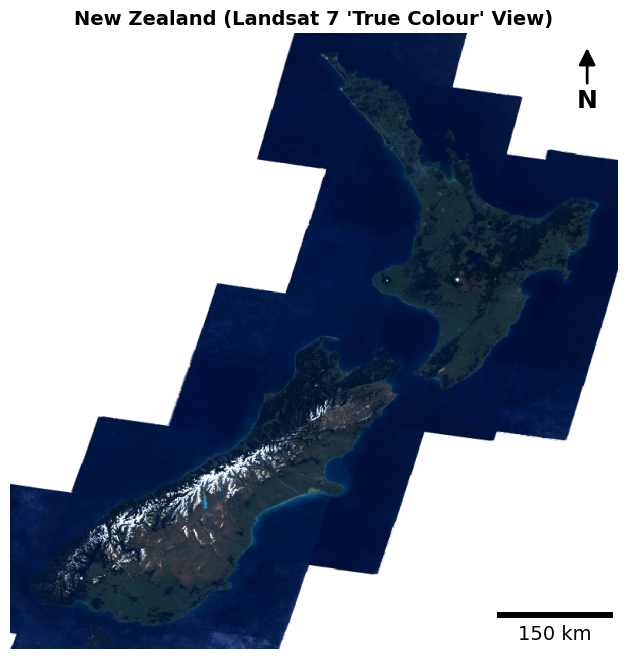

In [96]:
import ee
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

# --- Define region of interest (matches Map3's center/zoom roughly) ---
region = ee.Geometry.Rectangle([166, -47, 179, -34])  # covers New Zealand

landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")

# --- Fetch Landsat 7 thumbnail ---
landsat_vis = {"bands": ["B3", "B2", "B1"], "min": 10, "max": 80, "region": region, "dimensions": 800}
landsat_url = landsat7.getThumbURL(landsat_vis)
landsat_img = Image.open(BytesIO(requests.get(landsat_url).content))

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(landsat_img)
ax.set_title("New Zealand (Landsat 7 'True Colour' View)", fontsize=14, fontweight="bold")
ax.axis("off")

# --- Proper-looking North arrow (top right) ---
x, y, arrow_length = 0.95, 0.98, 0.09
ax.annotate("N", xy=(x, y), xytext=(x, y - arrow_length),
            xycoords="axes fraction", textcoords="axes fraction",
            ha="center", va="center", fontsize=18, fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", facecolor="black",
                             edgecolor="black", linewidth=2,
                             mutation_scale=25))

# --- Scale bar (bottom right) ---
scalebar = ScaleBar(1, units="km", location="lower right",
                     box_alpha=0.6, color="black")
ax.add_artist(scalebar)


plt.savefig("/content/static_map3.png", dpi=200, bbox_inches="tight")
plt.show()

# Spectral reflectance curves
Next we we will generate a spectral reflectance curve for a given area.
This is a useful tool when you are considering if a given target has spectral characteristics for identification in ML. If everything has the same spectral signature, then you need to take a different approach to a simple spectral classification, as might have been the first instinct of a classical remote sensing scientist before the advent of machine learning.

In [64]:
# Add in a library for plotting the data we extract
import matplotlib.pyplot as plt

In [65]:
# Define a point and a small rectangular region around it
point = ee.Geometry.Point([174.7633, -36.8485])  # Auckland, NZ
region = point.buffer(150).bounds()  # ~300 m box

In [66]:
# Load a Landsat 7 Collection 2 Level 2 SR image (surface reflectance)
image = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
    .filterBounds(region) \
    .filterDate('2002-01-01', '2002-12-31') \
    .sort('CLOUD_COVER') \
    .first()

(4) Why are we using the surface reflectance (SR) here rather than the top of atmosphere (ToA)? (2 pt)

= The reason for using surface reflectance rather than top of atmosphere data in this situation is that it removes atmospheric scattering and absorption, thereby capturing the true intrinsic spectral signature. In contrast, the other option, top of atmosphere data, would remain distorted by the different atmospheric conditions.  

In [67]:
# Select surface reflectance bands and apply scale factor
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}

scale_factor = 2.75e-5  # From USGS documentation for Landsat C2 L2

(5) What is a 'scale factor' as has been used in the prior code cell, and why are they used in satellite data storage-to-processing workflows such as this? (2 pts)

= A scale factor enables conversion of the raw stored integer data into real surface reflectance values, which is important because satellite providers store data as compact integers to optimise memory storage and transfer speeds, thereby requiring analysts to restore these true physical fractions for more precise analysis.

**Important sidenote**

The 'reduce' operation is a key concept in the backend of how Google is storing and serving us large quanities of satellite data. GEE uses 'reducers' in multiple ways, many of which are not always immediately intuitive. Check out the docs for more information:

*   https://developers.google.com/earth-engine/guides/reducers_intro

Here we are using a reduce operation over the specified small sample area in order to find the mean of all the cells that lie within the region:

In [68]:
# Reduce region to mean reflectance
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6
)

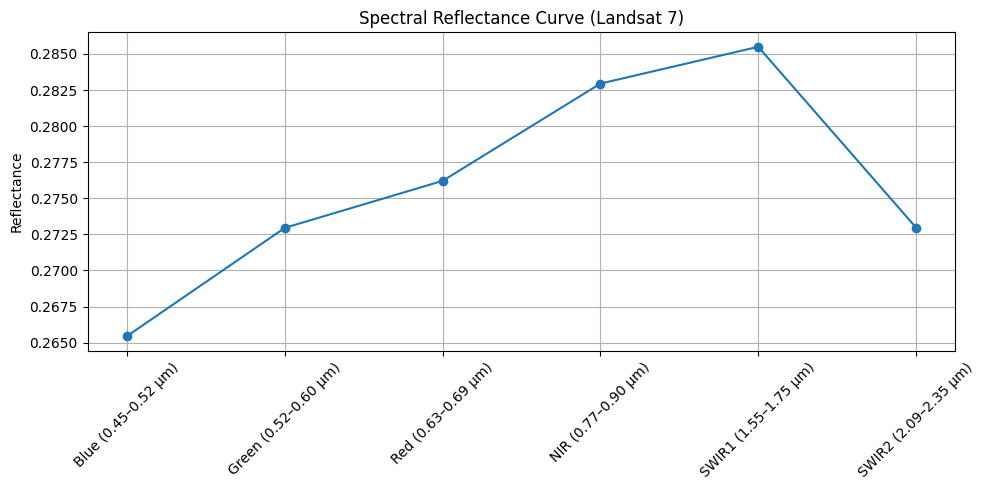

In [69]:
# Extract and scale values
mean_values = mean_dict.getInfo()
reflectance = [mean_values[b] * scale_factor for b in bands]

# Plot the spectral curve
plt.figure(figsize=(10, 5))
plt.plot(list(band_names.values()), reflectance, marker='o', linestyle='-')
plt.title('Spectral Reflectance Curve (Landsat 7)')
plt.ylabel('Reflectance')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

(6) If we want to apply multiple reducers to the same inputs what is a more efficient way to do so than just writing out a long series of sequential reducers on our end? (2 pts)

= An efficient approach utilises the ee.reducer.Combine() with sharedInputs set to TRUE to compute multiple reducers in a single pass over the pixel data, which helps avoid the computational overhead of running multiple sequential calls.  

# Cloud cover
A final consideration that I want to cover in this lab is that of cloud cover. Cloud cover removal is a complex and often difficut process that GISCI 341 students spend an entire two weeks tackling as a focus (so use them in your teams!). However, for our purpose here lets just use the basic in-built cloud clearing native to the Landsat 7 collection on GEE.

In [70]:
# Define small region around Auckland, NZ
point = ee.Geometry.Point([174.7633, -36.8485])
region = point.buffer(500).bounds()

# Load the image with least cloud cover in 2002
image = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2") \
    .filterBounds(region) \
    .filterDate("2002-01-01", "2002-12-31") \
    .sort("CLOUD_COVER") \
    .first() #<- note the filtering step that is being applied here! We are taking the first image in a sorted by cloud cover response.

# Check metadata
print('Image ID:', image.get('LANDSAT_PRODUCT_ID').getInfo())
print('Cloud Cover (whole scene):', image.get('CLOUD_COVER').getInfo())

Image ID: LE07_L2SP_073086_20020827_20200916_02_T1
Cloud Cover (whole scene): 1


In [71]:
# Function to mask clouds using QA_PIXEL band
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    # Bits 3 and 4 are cloud and cloud shadow respectively
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(
                 qa.bitwiseAnd(1 << 4).eq(0))
    return image.updateMask(cloud_mask)

# Apply mask
masked_image = mask_clouds(image)

**Important side note**

In the function above we are using a bitwise operation in order to search through the quality assurance (QA) band of the image. Different satellites have different bit-masks. Read more about bitmasks and how they are used here:
*   https://spatialthoughts.com/2021/08/19/qa-bands-bitmasks-gee/



**Another important side note**

You will have noticed that we are frequently running code and not seeing anything happen in terms of output in the cell or changes in the RAM/Disk of the Colab instance (check the small graphs top right). This is deliberate! Satellite data is large and hard to wrangle. GEE does a lot of the work for us, hence we can explore and get into it so quickly. Part of how it does this is by not executing any of your API calls until you specifically ask for an output to be sent back to you. Prior to calling an output (usually through a 'AddLayer' or similar call), when using the GEE/EE API you are essentially chaining together a lot of dot-operators (e.g. '.sort \ .reduce') into a series of instructions that are verified, but only then acted on when required.

This is the result of a 'client vs. server' approach. For more detail, that will help you understand why you can and cannot do certain things, see:
*   https://developers.google.com/earth-engine/guides/client_server



In [72]:
# Report Image Quality Over ROI
# Total pixels in region
pixel_area = ee.Image.pixelArea().clip(region)

# Count valid pixels before and after masking
total_pixels = pixel_area.reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=30,
    maxPixels=1e9
).getInfo()['area']

valid_pixels = masked_image.select('SR_B3').reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=30,
    maxPixels=1e9
).getInfo()['SR_B3']

cloud_coverage_pct = 100 * (1 - valid_pixels / total_pixels)

print(f"Total Pixels: {total_pixels}")
print(f"Valid (non-cloud) Pixels: {valid_pixels}")
print(f"Estimated Cloud Coverage in ROI: {cloud_coverage_pct:.2f}%")

Total Pixels: 1394
Valid (non-cloud) Pixels: 1050
Estimated Cloud Coverage in ROI: 24.68%


In [73]:
# Visualize the before and after
Map = geemap.Map(center=[-36.8485, 174.7633], zoom=12)

vis = {
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0,
    'max': 30000,
    'gamma': 1.4
}

Map.addLayer(image, vis, 'Original Image (Cloudy)')
Map.addLayer(masked_image, vis, 'Cloud Masked')
Map

Map(center=[-36.8485, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

(7) Produce a table that tells me the average amount of cloud cover per LandSat image in a year: for 2005, 2010 and 2015. Do this over a region of your choice, as a percentage.

Provide a notebook example of your code that does so, in addition to your table. (5 pts)

In [79]:
import pandas as pd  # This package in regards to the adjusting the table output
from IPython.display import display  # Re-import to avoid clash with pyvirtualdisplay's 'display' variable

# Defining Auckland City area (ROI)
point = ee.Geometry.Point([174.7633, -36.8485]);
region = point.buffer(500).bounds();

# Cloud masking function using 'QA_PIXEL' band
def maskClouds(image):
  qa = image.select('QA_PIXEL');
  cloudShadowMask = qa.bitwiseAnd(1 << 4).eq(0);
  cloudMask = qa.bitwiseAnd(1 << 3).eq(0);
  return image.updateMask(cloudShadowMask.And(cloudMask))

# Doing initial calculations of the total pixels in the ROI
totalPixels = ee.Image.pixelArea().clip(region).reduceRegion(
    reducer = ee.Reducer.count(),
    geometry = region,
    scale = 30,
    maxPixels = 1e9
  ).get('area')

# Evaluating the annual cloud cover metrics
def getAnnualStats(year):
    startDate = ee.Date.fromYMD(year, 1, 1)
    endDate = ee.Date.fromYMD(year, 12, 31)

    collection = (
        ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
        .filterBounds(region)
        .filterDate(startDate, endDate)
    )

    def process_scene(img):
        masked = maskClouds(img)  # fixed: was mask_clouds (undefined)
        valid_pixels = masked.select('SR_B3').reduceRegion(
            reducer=ee.Reducer.count(),
            geometry=region,
            scale=30,
            maxPixels=1e9
        ).get('SR_B3')

        valid = ee.Number(ee.Algorithms.If(valid_pixels, valid_pixels, 0))
        roi_cloud_pct = ee.Number(100).subtract(valid.divide(totalPixels).multiply(100))

        return img.set({
            'roi_cloud_pct': roi_cloud_pct,
            'scene_cloud_cover': img.get('CLOUD_COVER')
        })

    processed = collection.map(process_scene)

    return ee.Feature(None, {
        'Year': year,
        'Total_Images': processed.size(),
        'Avg_ROI_Cloud_Pct': processed.aggregate_mean('roi_cloud_pct'),
        'Avg_Scene_Cloud_Pct': processed.aggregate_mean('scene_cloud_cover')
    })

# Generating and printing out the FeatureCollection as a table
target_years = ee.List([2005, 2010, 2015])
annual_table = ee.FeatureCollection(target_years.map(getAnnualStats))

# Extracting Google Earth Engine properties to then convert to cleaning the Pandas table
data = [f['properties'] for f in annual_table.getInfo()['features']]
df = pd.DataFrame(data)

# Formatting the headers and round percentages
df = df[['Year', 'Total_Images', 'Avg_Scene_Cloud_Pct', 'Avg_ROI_Cloud_Pct']].round(2)
df.columns = ['Year', 'Total Images', 'Average Scene Cloud (%)', 'Average ROI Cloud (%)']

# Displaying the more cleaned up table output
display(df.style.hide(axis="index"))



## Reference to the use of the QA_Pixel = https://www.usgs.gov/media/files/landsat-4-7-collection-2-level-2-science-product-guide
## Reference to using the aggregate mean = https://developers.google.com/earth-engine/apidocs/ee-featurecollection-aggregate_mean
## Reference to the using the return date function = https://developers.google.com/earth-engine/apidocs/ee-date-fromymd

Year,Total Images,Average Scene Cloud (%),Average ROI Cloud (%)
2005,55,46.290000,75.360000
2010,59,43.690000,81.010000
2015,60,48.750000,77.470000


In [77]:
# Downloading the package required to exporting the table above as a png (now downloaded)
!pip install dataframe_image

import dataframe_image as dfi
from google.colab import files

# Exporting using matplotlib engine
dfi.export(df, 'cloud_summary_table.png', table_conversion='matplotlib')

# Downloading exported table image to the computer
files.download('cloud_summary_table.png')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 18.2 MB/s eta 0:00:00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final exercise
Let us now be very fancy and plot our spectral reflectance curve along with a display of the satellite data that it was generated from. As well as being fancy, this lets us see that what we have done here is sample the urban fabric of downtown Auckland and collect the spectral signature of 'urban'.

The code block below is large and calls in some further packages as we start to push beyond what is already built into geemap. I have also placed all the required code in one cell as I am about to ask you to do something with it... Make sure that you take the time understand what each section is doing and why. Consider starting to break this code down into functions that you can re-use later. If you do not know what I mean by this, please ask! (And Google 'modular code design, functions').

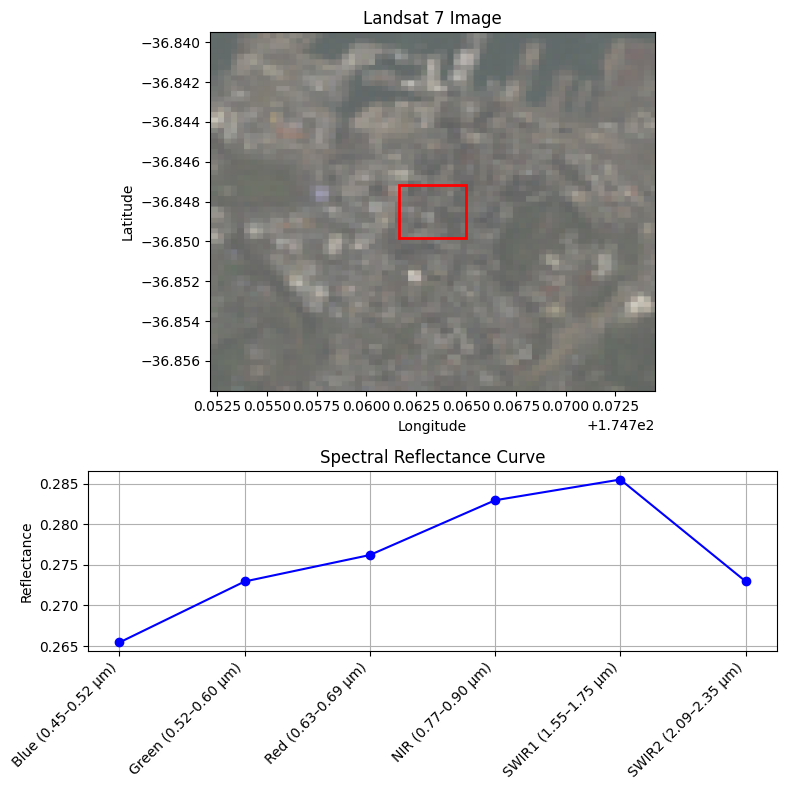

In [ ]:
# Additional required packages
import matplotlib.patches as patches
import urllib.request
import tempfile
import matplotlib.image as mpimg

# Define point and regions
point = ee.Geometry.Point([174.7633, -36.8485])
region = point.buffer(150).bounds()        # ~300 m box
expanded_region = point.buffer(1000).bounds()  # box for image preview

# Load Landsat 7 surface reflectance image
image = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
    .filterBounds(region) \
    .filterDate('2002-01-01', '2002-12-31') \
    .sort('CLOUD_COVER') \
    .first()

# Define bands and scaling
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}
scale_factor = 2.75e-5

# Calculate mean reflectance
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6).getInfo()

reflectance = [mean_dict[b] * scale_factor for b in bands]
labels = list(band_names.values())

# Get RGB thumbnail slightly zoomed out
thumb_params = {
    'dimensions': 512,
    'region': expanded_region,
    'format': 'png',
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0,
    'max': 30000,
    'gamma': 1.4
}
url = image.getThumbURL(thumb_params)

# Get coordinates of regions
def get_bounds_coords(bounds):
    coords = bounds.coordinates().getInfo()[0]
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    return min(lons), max(lons), min(lats), max(lats)

# Extract bounding boxes
xmin, xmax, ymin, ymax = get_bounds_coords(expanded_region)
rxmin, rxmax, rymin, rymax = get_bounds_coords(region)

# Plot both panels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [2, 1]})

# Load and plot image with annotation
with tempfile.NamedTemporaryFile(suffix=".png") as f:
    urllib.request.urlretrieve(url, f.name)
    img = mpimg.imread(f.name)
    ax1.imshow(img, extent=[xmin, xmax, ymin, ymax])
    ax1.set_title("Landsat 7 Image")
    ax1.set_xlim(xmin, xmax)
    ax1.set_ylim(ymin, ymax)

    # Add red rectangle for region of interest
    width = rxmax - rxmin
    height = rymax - rymin
    rect = patches.Rectangle((rxmin, rymin), width, height,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)
    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")

# Plot reflectance
ax2.plot(labels, reflectance, marker='o', color='blue')
ax2.set_title("Spectral Reflectance Curve")
ax2.set_ylabel("Reflectance")
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.grid(True)

plt.tight_layout()
plt.show()


(8) Exercise: Using Sentinel 2, create a figure that does the following over the city of Christchurch, NZ:
*   Conduct a basic quality assessment of the data you use by stating how much of your area is covered by cloud.
* Show the spectral reflectance signatures of: urban, forest, grassland, water and bare soil. Using a line graph that stacks them all onto the same axes.
* Gives examples of the sample areas that you have used to create these spectral signatures.

Provide a publication quality copy of this figure in the answer proforma. Publication quality means that:  
1.   It is at a good quality (resolution) and not blurry.
2.   The font size of all elements is big enough to read easily on a screen when placed in the document.
3. Has a figure caption that ensures the reader knows what you have done and why.
4. Tells the story 'at a glance'. Don't make your viewer work too hard to understand your core message.

See the Nature guide linked at the start of this lab for more detail on what I expect.

(25 pts)




Data Quality Assessment: Scene Cloud Cover = 2.01%


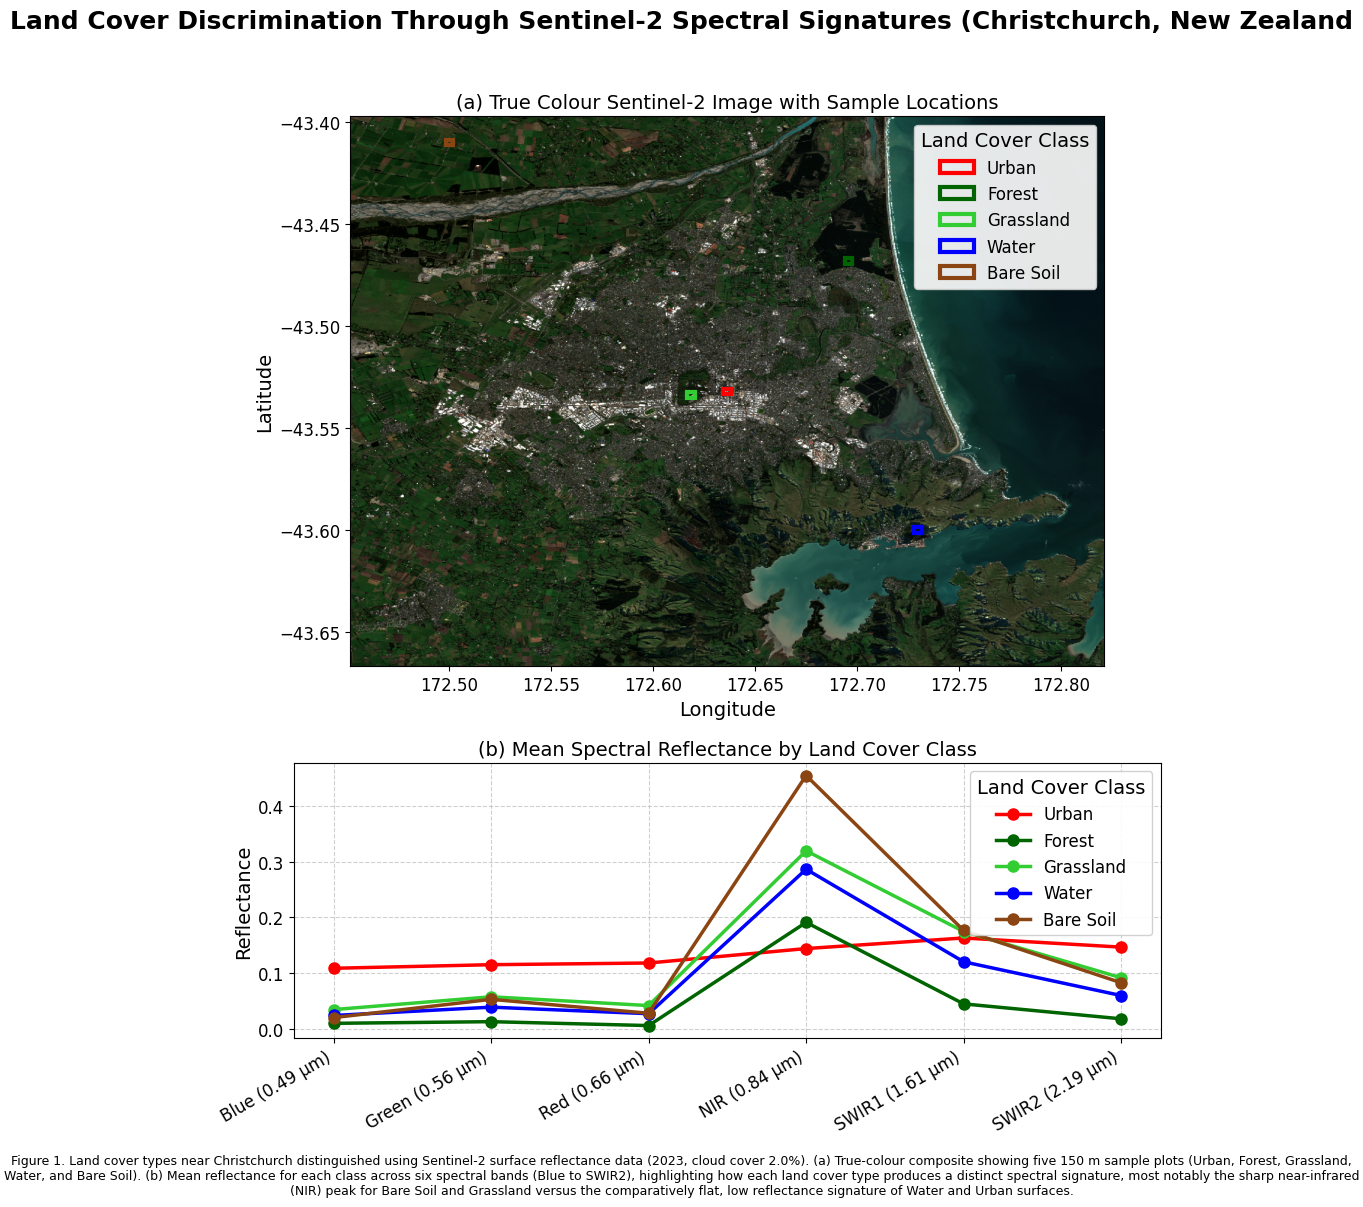

In [98]:
# Loading up a few packages that are needed for this task again
import tempfile
import urllib.request
import ee
import matplotlib.image as mpimg
import matplotlib.patches as patches
import matplotlib.pyplot as plt

# --- Global font sizing for publication quality (readable at document/slide scale) ---
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})

# Defining main Christchurch area and sample points for the 5 target land cover classes
christchurch_center = ee.Geometry.Point([172.6362, -43.5321])
expanded_region = christchurch_center.buffer(15000).bounds()

# Defining small sample areas similarly done in the Auckland example for each land cover type
samples = {
    "Urban": {
        "region": ee.Geometry.Point([172.6362, -43.5321]).buffer(150).bounds(),
        "color": "red",
    },
    "Forest": {
        "region": ee.Geometry.Point([172.6958, -43.4682]).buffer(150).bounds(),
        "color": "darkgreen",
    },
    "Grassland": {
        "region": ee.Geometry.Point([172.6185, -43.5338]).buffer(150).bounds(),
        "color": "limegreen",
    },
    "Water": {
        "region": ee.Geometry.Point([172.7300, -43.6000]).buffer(150).bounds(),
        "color": "blue",
    },
    "Bare Soil": {
        "region": ee.Geometry.Point([172.5000, -43.4100]).buffer(150).bounds(),
        "color": "saddlebrown",
    },
}

# Loading Sentinel 2 Surface Reflectance image which hovers over Christchurch
image = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(expanded_region)
    .filterDate("2023-01-01", "2023-04-30")
    .sort("CLOUDY_PIXEL_PERCENTAGE")
    .first()
)

# Proceeding with Quality Assessment (QA)
cloud_cover = image.get("CLOUDY_PIXEL_PERCENTAGE").getInfo()
print(f"Data Quality Assessment: Scene Cloud Cover = {cloud_cover:.2f}%")

# Defining the Sentinel 2 bands and adjusting the new scaling factor
bands = ["B2", "B3", "B4", "B8", "B11", "B12"]
band_names = {
    "B2": "Blue (0.49 µm)",
    "B3": "Green (0.56 µm)",
    "B4": "Red (0.66 µm)",
    "B8": "NIR (0.84 µm)",
    "B11": "SWIR1 (1.61 µm)",
    "B12": "SWIR2 (2.19 µm)",
}
scale_factor = 0.0001  # Sentinel-2 L2A surface reflectance scaling
labels = list(band_names.values())

# Calculating mean reflectance for each land cover sample
reflectance_data = {}
for name, info in samples.items():
    mean_dict = (
        image.select(bands)
        .reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=info["region"],
            scale=10,
            maxPixels=1e6,
        )
        .getInfo()
    )
    reflectance_data[name] = [mean_dict[b] * scale_factor for b in bands]

# Retrieving the RGB thumbnail for preview (higher resolution for print quality)
thumb_params = {
    "dimensions": 1024,  # bumped up from 512 for sharper output at print size
    "region": expanded_region,
    "format": "png",
    "bands": ["B4", "B3", "B2"],  # true RGB colours
    "min": 0,
    "max": 3000,
}
url = image.getThumbURL(thumb_params)

# Helper function to extract bounding coordinates
def get_bounds_coords(bounds):
    coords = bounds.coordinates().getInfo()[0]
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    return min(lons), max(lons), min(lats), max(lats)

xmin, xmax, ymin, ymax = get_bounds_coords(expanded_region)

# Plotting both panels (Map Preview + Stacked Spectral Signatures)
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 12), gridspec_kw={"height_ratios": [2, 1]}
)

fig.suptitle(
    "Land Cover Discrimination Through Sentinel-2 Spectral Signatures (Christchurch, New Zealand",
    fontweight="bold", y=0.995
)

# Panel 1: Map Image with Annotated Sample Locations
with tempfile.NamedTemporaryFile(suffix=".png") as f:
    urllib.request.urlretrieve(url, f.name)
    img = mpimg.imread(f.name)
    ax1.imshow(img, extent=[xmin, xmax, ymin, ymax])
    ax1.set_title("(a) True Colour Sentinel-2 Image with Sample Locations", fontsize=14)
    ax1.set_xlim(xmin, xmax)
    ax1.set_ylim(ymin, ymax)
    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")

    # Drawing the colored rectangles for each sample area — thicker + larger for visibility
    for name, info in samples.items():
        s_xmin, s_xmax, s_ymin, s_ymax = get_bounds_coords(info["region"])
        rect = patches.Rectangle(
            (s_xmin, s_ymin),
            s_xmax - s_xmin,
            s_ymax - s_ymin,
            linewidth=3,
            edgecolor=info["color"],
            facecolor="none",
            label=name,
        )
        ax1.add_patch(rect)

    ax1.legend(loc="upper right", framealpha=0.9, title="Land Cover Class")

# Panel 2: Stacked Spectral Reflectance Curves
for name, values in reflectance_data.items():
    ax2.plot(
        labels,
        values,
        marker="o",
        markersize=8,
        label=name,
        color=samples[name]["color"],
        linewidth=2.5,
    )

ax2.set_title("(b) Mean Spectral Reflectance by Land Cover Class", fontsize=14)
ax2.set_ylabel("Reflectance")
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=30, ha="right")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend(loc="upper right", framealpha=0.9, title="Land Cover Class")

plt.tight_layout(rect=[0, 0.04, 1, 0.98])

# --- Figure caption, placed directly beneath the figure ---
caption = (
    "Figure 1. Land cover types near Christchurch distinguished using Sentinel-2 "
    "surface reflectance data (2023, cloud cover {:.1f}%). (a) True colour composite showing five "
    "150 m sample plots (Urban, Forest, Grassland, Water, and Bare Soil). (b) Mean reflectance for "
    "each class across six spectral bands (Blue to SWIR2), highlighting how each land cover type "
    "produces a distinct spectral signature, particularly the sharp near-infrared (NIR) peak for "
    "Bare Soil and Grassland versus the comparatively flat, low reflectance signature of Water and Urban surfaces."
).format(cloud_cover)

fig.text(0.5, 0.005, caption, ha="center", va="bottom", fontsize=9, wrap=True)

# --- Save at high resolution for publication use ---
plt.savefig("/content/sentinel2_landcover_figure.png", dpi=300, bbox_inches="tight")
plt.show()

# Reference link to using sentinel 2 surface reflectance codes = https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED
# Reference link to adopting the use of sentinel 2 bands = https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Data/S2L2A.html
